# Actividad práctica: series temporales
### Análisis y aplicación sobre datos de turismo internacional Argentina

Esta actividad tiene tres momentos. Los dos primeros son de análisis visual — no requieren código. El tercero aplica lo visto en las píldoras sobre el dataset de turismo que ya conocés.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

---

## ACTIVIDAD 1 — ¿La serie es estacionaria?

Una serie es **estacionaria** cuando su media y su varianza son constantes en el tiempo — no tiene tendencia ni cambios de nivel sistemáticos.

Observá los tres gráficos y respondé las preguntas para cada serie.

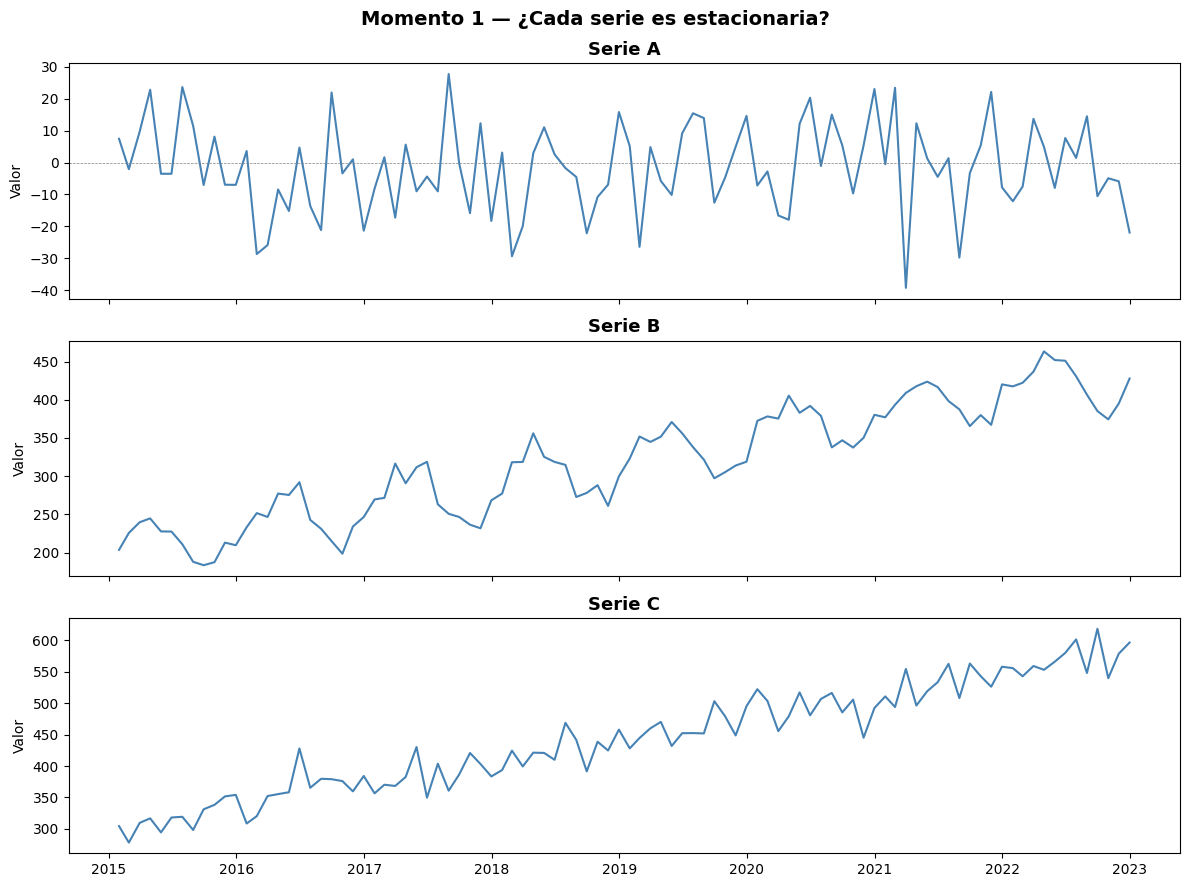

In [ ]:
# Generación de las series act 1
np.random.seed(42)
fechas = pd.date_range('2015-01-01', periods=96, freq='ME')
t = np.arange(96)

# Serie A:
serie_a = np.random.normal(0, 15, 96)

# Serie B:
serie_b = 200 + 2.5*t + 40*np.sin(2*np.pi*t/12) + np.random.normal(0, 12, 96)

# Serie C:
serie_c = 300 + 3*t + np.random.normal(0, 20, 96)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.patch.set_facecolor('white')

axes[0].plot(fechas, serie_a, color='steelblue', linewidth=1.5)
axes[0].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[0].set_title('Serie A', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor')

axes[1].plot(fechas, serie_b, color='steelblue', linewidth=1.5)
axes[1].set_title('Serie B', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Valor')

axes[2].plot(fechas, serie_c, color='steelblue', linewidth=1.5)
axes[2].set_title('Serie C', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Valor')

plt.suptitle('Momento 1 — ¿Cada serie es estacionaria?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Preguntas — respondé en esta celda

**Serie A:**
- ¿Es estacionaria? ¿Por qué?
- ¿Tiene tendencia? ¿Tiene estacionalidad?
- ¿Qué diferenciación aplicarías antes de usar ARIMA? (`diff(1)`, `diff(12)`, ambas, o ninguna)

*Tu respuesta:*

---

**Serie B:**
- ¿Es estacionaria? ¿Por qué?
- ¿Tiene tendencia? ¿Tiene estacionalidad?
- ¿Qué diferenciación aplicarías antes de usar ARIMA?

*Tu respuesta:*

---

**Serie C:**
- ¿Es estacionaria? ¿Por qué?
- ¿Tiene tendencia? ¿Tiene estacionalidad?
- ¿Qué diferenciación aplicarías antes de usar ARIMA?

*Tu respuesta:*

### ACTIVIDAD 2-Preguntas — respondé en esta celda

Para cada serie indicá: **aditiva** o **multiplicativa**, y en una línea justificá mirando el gráfico.

| Serie | ¿Aditiva o multiplicativa? | Justificación |
|---|---|---|
| Serie 1 | | |
| Serie 2 | | |
| Serie 3 | | |
| Serie 4 | | |

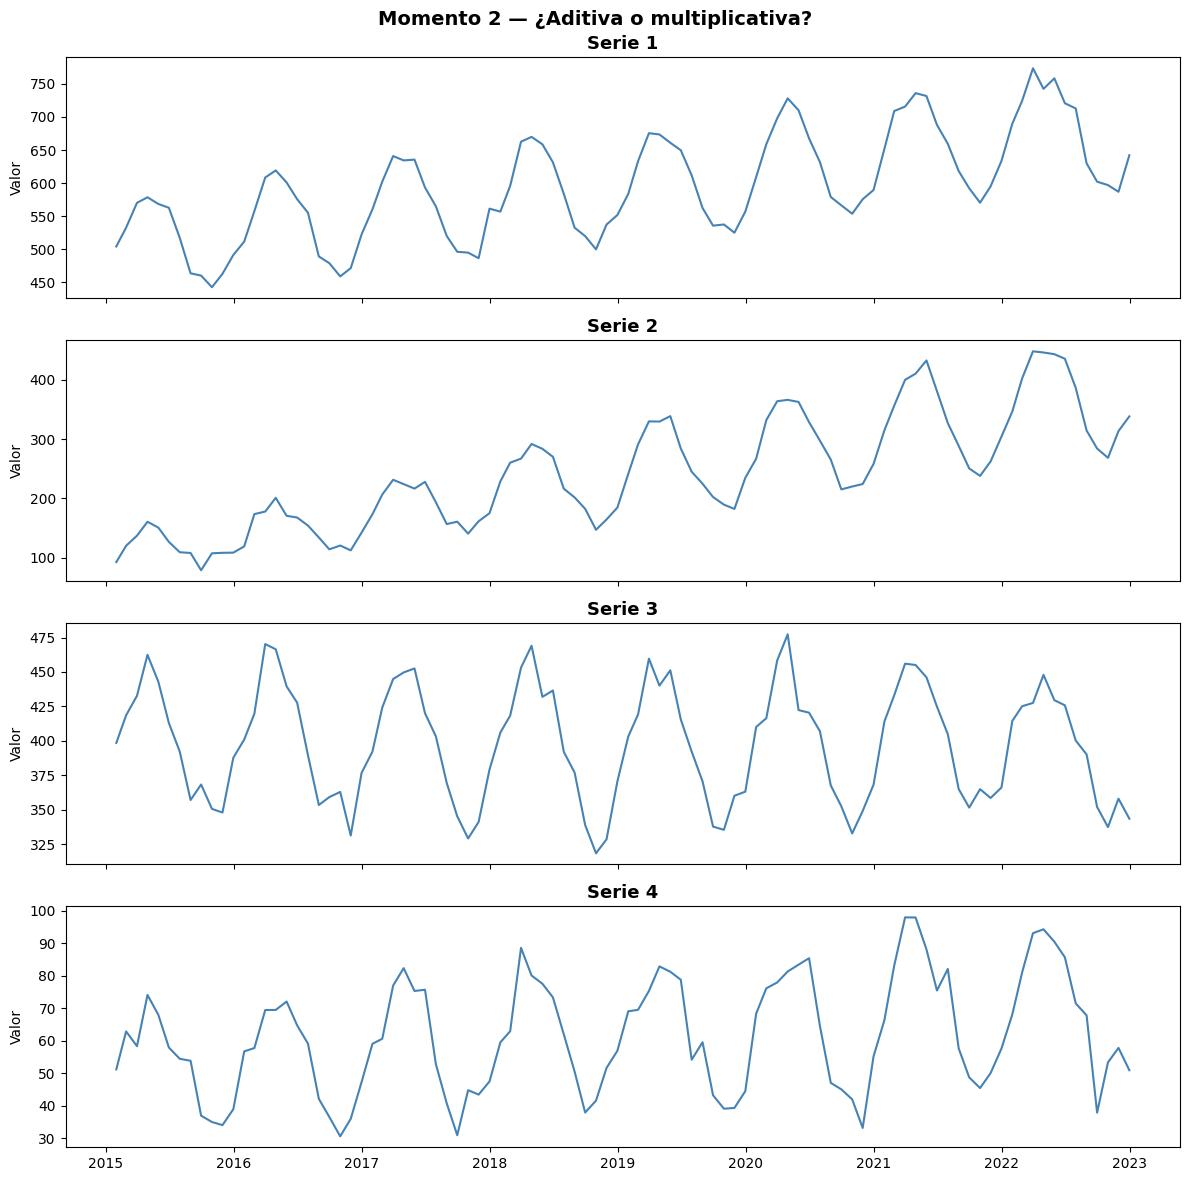

In [ ]:
# Generación de las series act 2
# Serie 1:
s1_tend = 500 + 2*t
serie_1 = s1_tend + 80*np.sin(2*np.pi*t/12) + np.random.normal(0, 15, 96)

# Serie 2:
s2_tend = 100 + 3*t
serie_2 = s2_tend * (1 + 0.3*np.sin(2*np.pi*t/12)) + np.random.normal(0, 10, 96)

# Serie 3:
serie_3 = 400 + 60*np.sin(2*np.pi*t/12) + np.random.normal(0, 12, 96)

# Serie 4:
s4_tend = 50 * np.exp(0.025*t/12*2)
serie_4 = s4_tend * (1 + 0.35*np.sin(2*np.pi*t/12)) + np.random.normal(0, 5, 96)

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
fig.patch.set_facecolor('white')

for ax, serie, label in zip(axes,
    [serie_1, serie_2, serie_3, serie_4],
    ['Serie 1', 'Serie 2', 'Serie 3', 'Serie 4']):
    ax.plot(fechas, serie, color='steelblue', linewidth=1.5)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_ylabel('Valor')

plt.suptitle('Momento 2 — ¿Aditiva o multiplicativa?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## ACTIVIDAD 3 — Aplicación sobre turismo internacional Argentina

Ahora trabajás con el dataset de turismo que ya conocés. El objetivo es aplicar los conceptos de las píldoras tomando decisiones justificadas en cada paso.

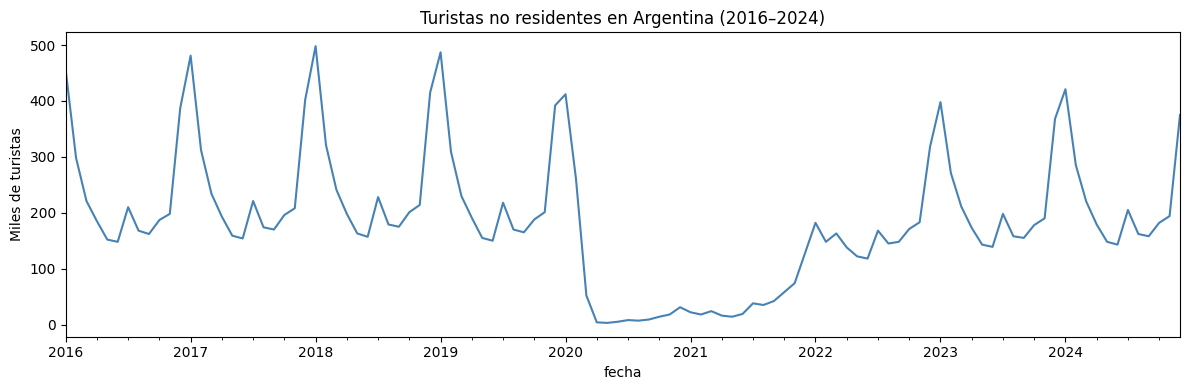

In [ ]:
# Cargar y preparar el dataset de turismo
df = pd.read_csv('turismo_internacional_argentina.csv')
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')
serie = df['turistas_no_residentes_miles']

serie.plot(figsize=(12, 4),
           title='Turistas no residentes en Argentina (2016–2024)',
           ylabel='Miles de turistas', color='steelblue')
plt.tight_layout()
plt.show()

### Paso A — Antes de descomponer, tomá decisiones

Respondé estas preguntas mirando el gráfico anterior. Las respuestas van a guiar el código de los pasos siguientes.

1. ¿La serie de turismo es estacionaria? ¿Por qué?
2. ¿Usarías descomposición aditiva o multiplicativa? Justificá mirando si la amplitud de la estacionalidad cambia con el nivel.
3. Si tuvieras que aplicar ARIMA, ¿qué diferenciaciones necesitaría esta serie?

*Tus respuestas:*

### Paso B — Descomposición clásica

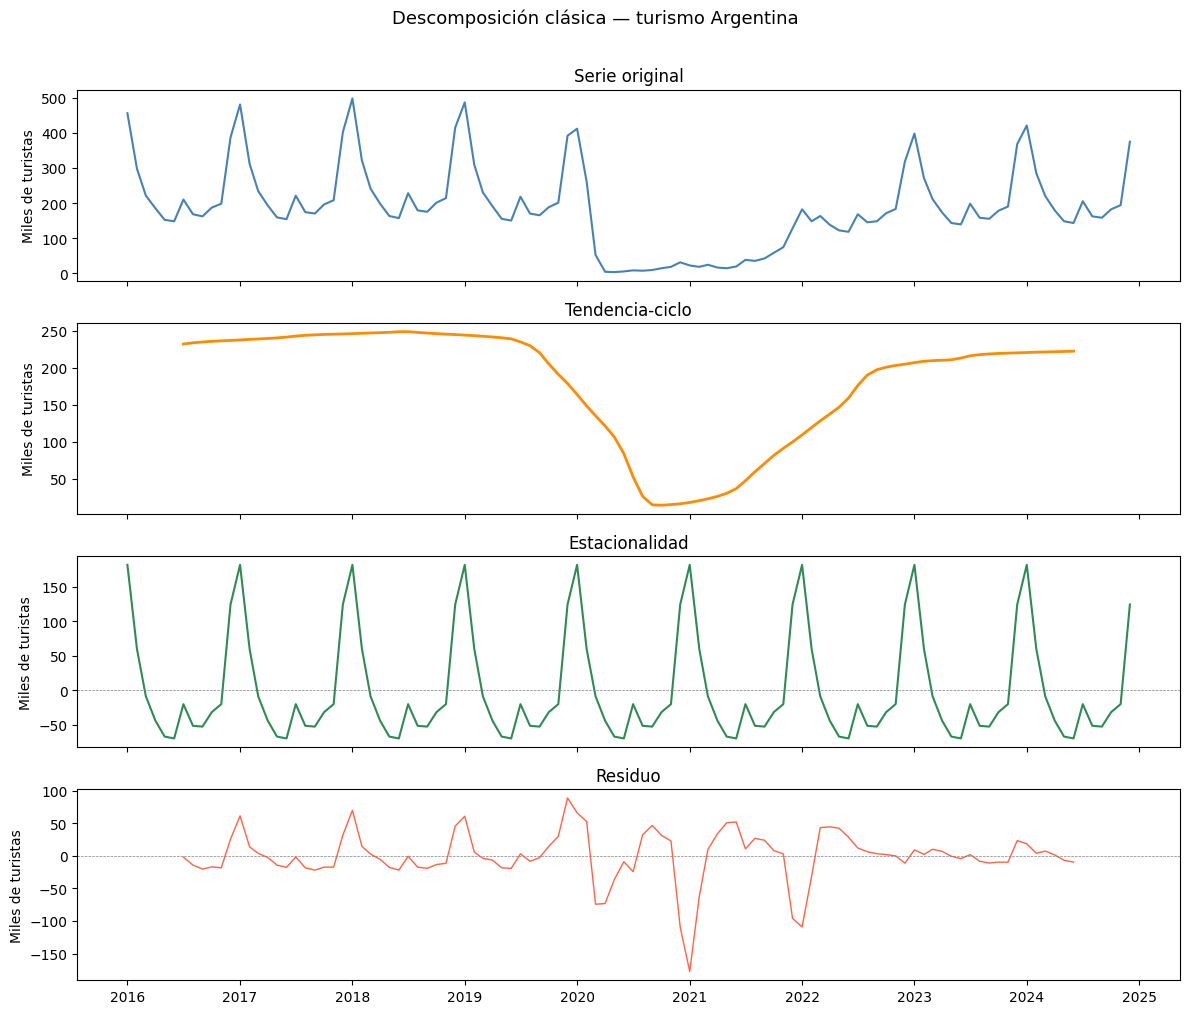

In [ ]:
# Aplicar seasonal_decompose con el modelo que elegiste en el Paso A
# Completá el parámetro model= con 'additive' o 'multiplicative' según tu decisión
descomp = seasonal_decompose(
    serie,
    model= ___,      # ← completar con tu decisión del Paso A
    period=12
)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(serie,              color='steelblue',  linewidth=1.5)
axes[0].set_title('Serie original')
axes[1].plot(descomp.trend,      color='darkorange',  linewidth=2)
axes[1].set_title('Tendencia-ciclo')
axes[2].plot(descomp.seasonal,   color='seagreen',   linewidth=1.5)
axes[2].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[2].set_title('Estacionalidad')
axes[3].plot(descomp.resid,      color='tomato',     linewidth=1)
axes[3].axhline(0, color='gray', linewidth=0.5, linestyle='--')
axes[3].set_title('Residuo')

for ax in axes:
    ax.set_ylabel('Miles de turistas')

plt.suptitle('Descomposición clásica — turismo Argentina', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

**Interpretá los cuatro paneles:**

- ¿Qué muestra la tendencia? ¿En qué períodos crece, cae o se estanca?
- ¿En qué meses la estacionalidad es positiva (más turistas de lo esperado) y en cuáles es negativa?
- ¿Qué aparece en el residuo? ¿Podés identificar el evento que genera el residuo más extremo?
- ¿Por qué los primeros y últimos valores de la tendencia son NaN?

*Tus respuestas:*

### Paso C — Descomposición STL

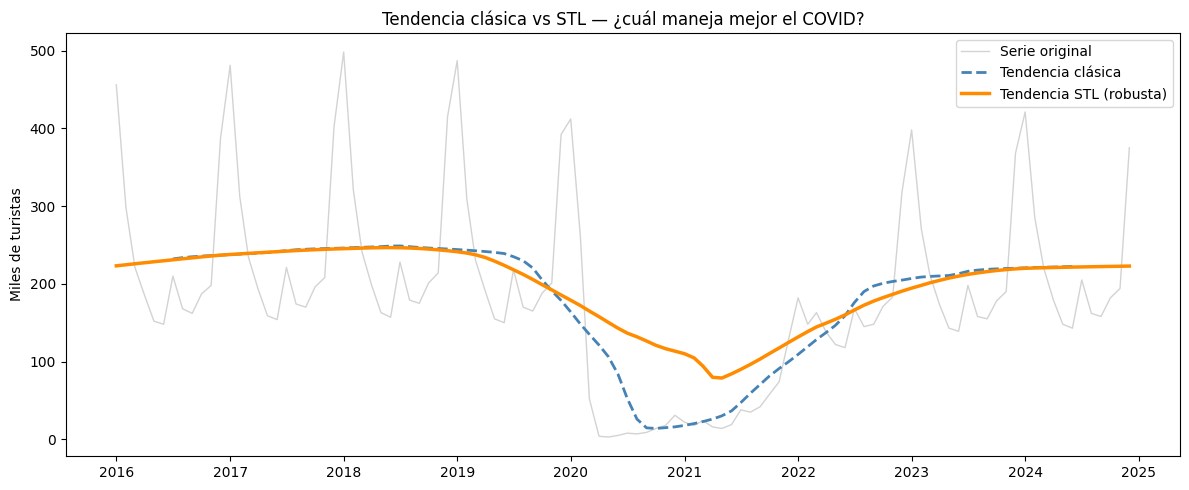

In [ ]:
# Aplicar STL con robust=True
stl = STL(serie, period=12, robust=True)
resultado_stl = stl.fit()

# Comparar la tendencia clásica vs STL
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(serie,                color='lightgray',   linewidth=1,   label='Serie original')
ax.plot(descomp.trend,        color='steelblue',   linewidth=2,   label='Tendencia clásica', linestyle='--')
ax.plot(resultado_stl.trend,  color='darkorange',  linewidth=2.5, label='Tendencia STL (robusta)')

ax.set_title('Tendencia clásica vs STL — ¿cuál maneja mejor el COVID?')
ax.set_ylabel('Miles de turistas')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretá la comparación:**

- ¿En qué se diferencia la tendencia STL de la tendencia clásica durante el período 2020–2021?
- ¿Cuál de las dos usarías para responder la pregunta: 'el turismo internacional en Argentina se recuperó estructuralmente después del COVID'? ¿Por qué?

*Tus respuestas:*